<h1>Medical Image Segmentation AI Model</h1>

This code uses the dataset from Cybele

In developing the model I have used the MONAI Documentation continuously: https://docs.monai.io/en/stable/networks.html

Additionally I have used inspiration from MONAI's Tutorial Repository: https://github.com/Project-MONAI/tutorials/blob/main/3d_segmentation/unet_segmentation_3d_ignite.ipynb

I have also used ChatGPT for help with errors and some debugging

In [2]:
import os
import glob
import torch
import matplotlib.pyplot as plt
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd, Resized, ToTensord, EnsureTyped
)
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.optimizers import Novograd
from monai.metrics import DiceMetric

<h3>Loading data</h3>

In [ ]:
# Use of ChatGPT for help with loading data
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"

case_dirs = sorted(glob.glob(os.path.join(base_dir, "*")))
data = []

for case_dir in case_dirs:
    case_id = os.path.basename(case_dir) 
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        data.append({"image": image_path, "label": label_path}) 
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(data)} samples.")

Found 130 samples.


<h3>Data Transformations</h3>

In [ ]:
# Transforms for data preprocessing
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]), # Loads the "nii.gz"-files into numpy arrays
    EnsureChannelFirstd(keys=["image", "label"]), # Ensures the channel is first as MONAI expects this: (C, H, W, D)
    NormalizeIntensityd(keys=["image"]), # Normalizes intensity of image voxels (3d-pixels)
    Resized(keys=["image", "label"], spatial_size=[512, 512, 80]), # Resize images and labels (Same size needed when loading more than one bathc)
    ToTensord(keys=["image", "label"]), # Converts numpy arrays to tensors (pytorch)
    EnsureTyped(keys=["image", "label"]), # Ensure the correct data types
])

# Dataset and DataLoader
train_dataset = Dataset(data=data, transform=train_transforms) # Applying transformations to the data
train_loader = DataLoader(train_dataset, batch_size=2) # Loads the data (in two parallel batches)

<h3> Building the Model </h3>

In [ ]:
# Define the UNet model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(
    spatial_dims=3, # 3D model (volumetric MRI data)
    in_channels=1, # Single-channel input (T2 MRI image -> greyscale)
    out_channels=1, # Single output channel (binary tumor mask)
    channels=(4, 8, 16, 32), # Number of filters at each layer
    strides=(2, 2, 2), # Strides for convs on each layer
).to(device)

# Loss function and optimizer
loss_function = DiceLoss(include_background=True, sigmoid=True) # Sigmoid for binary segmentation
optimizer = Novograd(model.parameters(), lr=1e-3) # Standard lr

# Dice metric for evaluation (similarity between predictions and ground truth)
dice_metric = DiceMetric(include_background=True, reduction="mean") # Standard settings

UNet:

- Encoder: (feature extraction)

    (1, 512, 512, 80) -> (4, 512, 512, 80) -> downsample by stride=2
    (4, 256, 256, 40) -> (8, 256, 256, 40) -> downsample by stride=2
    (8, 128, 128, 20) -> (16, 128, 128, 20) -> downsample by stride=2
    (16, 64, 64, 10) -> (32, 64, 64, 10) -> bottom level

- Decoder: (expanding path)

    (32, 64, 64, 10) -> (16, 128, 128, 20) # Concatination skip connected to layer 3 (out_chn = 16)
    (16, 128, 128, 20) -> (8, 256, 256, 40) # Concatination skip connected to layer 2 (out_chn = 8)
    (8, 256, 256, 40) -> (4, 512, 512, 80) # Concatination skip connected to layer 1 (out_chn = 4)
    
- Final Conv:

    apply 1x1x1 conv -> from 4 channels to 1 channel
    for each voxel: fin_output = w1*c1 + w2*c2 + w3*c3 + w4*c4 + b

<h3>Training the Model</h3>

In [26]:
# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0

    # Reset DiceMetric at the start of each epoch
    dice_metric.reset()

    for batch_data in train_loader:
        # Load data
        images = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        # Forward pass
        optimizer.zero_grad() # Clearing prev gradients
        outputs = model(images)
        outputs = torch.sigmoid(outputs) # Sigmoid for binary
        labels = (labels > 0).float() # Ensure labels are binary

        # Compute loss
        loss = loss_function(outputs, labels)
        epoch_loss += loss.item()

        # Compute dice metric
        dice_metric(y_pred=outputs, y=labels)
        # Use aggregate() to compute the mean dice score for the batch
        batch_dice = dice_metric.aggregate().item() # Get the scalar value
        epoch_dice += batch_dice

        # Backward pass
        loss.backward()
        optimizer.step() # Updates params using gradients from loss.backward()

    epoch_loss /= len(train_loader)
    epoch_dice /= len(train_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Dice: {epoch_dice:.4f}")

Epoch 1/5, Loss: 0.9953, Dice: 0.0001
Epoch 2/5, Loss: 0.9946, Dice: 0.0031
Epoch 3/5, Loss: 0.9943, Dice: 0.0156
Epoch 4/5, Loss: 0.9941, Dice: 0.0260
Epoch 5/5, Loss: 0.9940, Dice: 0.0395


<h3>Visualization</h3>

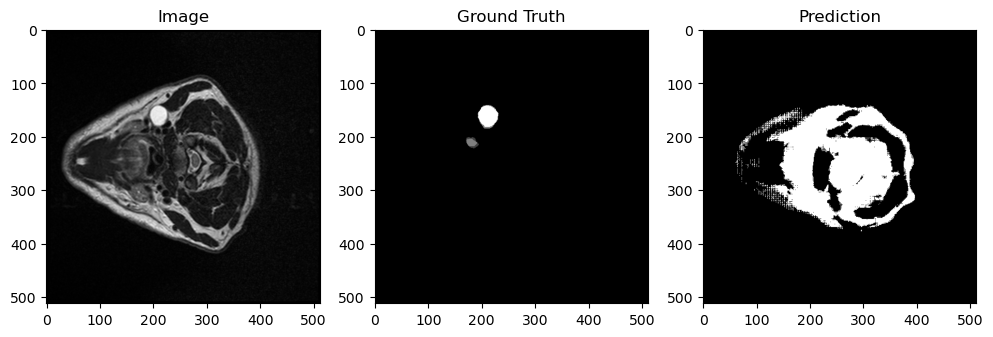

In [30]:
# Visualizing a sample from the test set
batch_data = next(iter(train_loader))
image = batch_data["image"][0].cpu().numpy()
label = batch_data["label"][0].cpu().numpy()
output = outputs[0].cpu().detach().numpy()

# Plot the original image, ground truth, and prediction
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image[0, :, :, 40], cmap="gray")
plt.title("Image")

plt.subplot(1, 3, 2)
plt.imshow(label[0, :, :, 40], cmap="gray")
plt.title("Ground Truth")

plt.subplot(1, 3, 3)
plt.imshow(output[0, :, :, 40] > 0.5, cmap="gray")  # Apply a threshold for the prediction
plt.title("Prediction")

plt.show()